# Loan Default Prediction

This notebook analyzes Lending Club loan data and builds machine learning models to predict loan default risk.

Steps covered:
- Data understanding
- Data cleaning
- Feature engineering
- Model building (Logistic Regression, Decision Tree, Random Forest)
- Evaluation using Precision, Recall, F1-score and ROC-AUC

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('german_credit_data.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1000, 9)

Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

First 5 rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [2]:
# Fill missing values first
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

# Map account levels to risk scores
saving_map = {
    'little': 2,
    'moderate': 1,
    'quite rich': -1,
    'rich': -2,
    'unknown': 1  # unknown treated as slightly risky
}

checking_map = {
    'little': 2,
    'moderate': 1,
    'rich': -2,
    'unknown': 1
}

# Build a risk score using financial logic
df['risk_score'] = (
    (df['Credit amount'] / df['Credit amount'].max()) * 3 +   # higher amount = riskier
    (df['Duration'] / df['Duration'].max()) * 2 +             # longer duration = riskier
    df['Saving accounts'].map(saving_map) +                   # less savings = riskier
    df['Checking account'].map(checking_map)                  # less in checking = riskier
)

# Convert score to binary target (top 30% riskiest = bad)
threshold = df['risk_score'].quantile(0.70)
df['Risk'] = (df['risk_score'] >= threshold).astype(int)  # 1 = bad, 0 = good

# Drop helper column
df.drop(columns=['risk_score'], inplace=True)

print(f"Target column created!")
print(f"\nRisk distribution:")
print(df['Risk'].value_counts())
print(f"\nDataset shape: {df.shape}")
df.head()

Target column created!

Risk distribution:
Risk
0    700
1    300
Name: count, dtype: int64

Dataset shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,unknown,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,1


In [3]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

C:\Users\USER\AppData\Local\Temp\ipykernel_1432\1445978123.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y='Credit amount', data=df,
C:\Users\USER\AppData\Local\Temp\ipykernel_1432\1445978123.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xticklabels(['Good', 'Bad'])
C:\Users\USER\AppData\Local\Temp\ipykernel_1432\1445978123.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y='Duration', data=df,
C:\Users\USER\AppData\Local\Temp\ipykernel_1432\1445978123.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

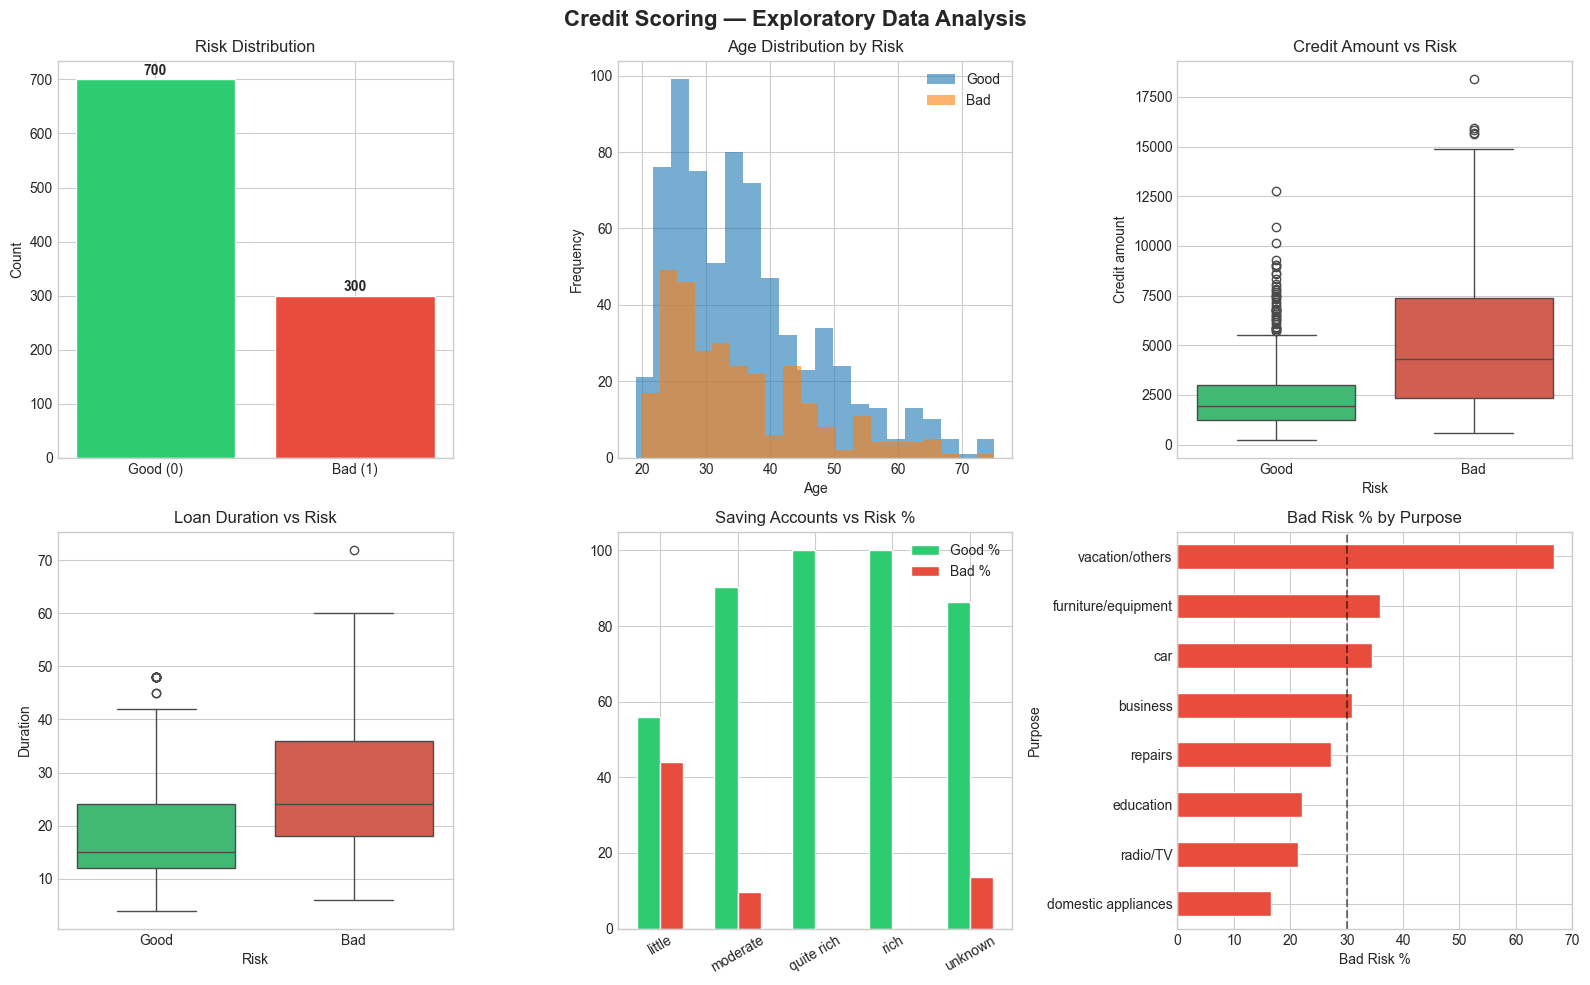


Key Stats:
  Avg Credit Amount — Good: 2391  Bad: 5325
  Avg Duration      — Good: 17.5m  Bad: 28.8m
  Avg Age           — Good: 35.9  Bad: 34.8


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Scoring — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution
axes[0,0].bar(['Good (0)', 'Bad (1)'], 
               df['Risk'].value_counts().values, 
               color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0,0].set_title('Risk Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['Risk'].value_counts().values):
    axes[0,0].text(i, v + 8, str(v), ha='center', fontweight='bold')

# 2. Age vs Risk
df.groupby('Risk')['Age'].plot(kind='hist', bins=20, alpha=0.6, 
                                ax=axes[0,1], legend=True)
axes[0,1].set_title('Age Distribution by Risk')
axes[0,1].set_xlabel('Age')
axes[0,1].legend(['Good', 'Bad'])

# 3. Credit Amount vs Risk
sns.boxplot(x='Risk', y='Credit amount', data=df, 
            palette=['#2ecc71','#e74c3c'], ax=axes[0,2])
axes[0,2].set_title('Credit Amount vs Risk')
axes[0,2].set_xticklabels(['Good', 'Bad'])

# 4. Duration vs Risk
sns.boxplot(x='Risk', y='Duration', data=df, 
            palette=['#2ecc71','#e74c3c'], ax=axes[1,0])
axes[1,0].set_title('Loan Duration vs Risk')
axes[1,0].set_xticklabels(['Good', 'Bad'])

# 5. Saving accounts vs Risk
ct = pd.crosstab(df['Saving accounts'], df['Risk'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1,1], color=['#2ecc71','#e74c3c'], 
        edgecolor='white', width=0.6)
axes[1,1].set_title('Saving Accounts vs Risk %')
axes[1,1].set_xlabel('')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=30)
axes[1,1].legend(['Good %', 'Bad %'])

# 6. Purpose vs Risk
ct2 = pd.crosstab(df['Purpose'], df['Risk'], normalize='index') * 100
ct2[1].sort_values().plot(kind='barh', ax=axes[1,2], 
                           color='#e74c3c', edgecolor='white')
axes[1,2].set_title('Bad Risk % by Purpose')
axes[1,2].set_xlabel('Bad Risk %')
axes[1,2].axvline(30, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Summary stats
print("\nKey Stats:")
print(f"  Avg Credit Amount — Good: {df[df.Risk==0]['Credit amount'].mean():.0f}  Bad: {df[df.Risk==1]['Credit amount'].mean():.0f}")
print(f"  Avg Duration      — Good: {df[df.Risk==0]['Duration'].mean():.1f}m  Bad: {df[df.Risk==1]['Duration'].mean():.1f}m")
print(f"  Avg Age           — Good: {df[df.Risk==0]['Age'].mean():.1f}  Bad: {df[df.Risk==1]['Age'].mean():.1f}")

In [5]:
import sys
!{sys.executable} -m pip install scikit-learn

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 1. Encode categorical columns ──────────────────────────
le = LabelEncoder()

cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ── 2. Feature Engineering ──────────────────────────────────
# Amount per month — measures repayment burden
df['amount_per_month'] = df['Credit amount'] / df['Duration']

# Age group — younger borrowers tend to be riskier
df['age_group'] = pd.cut(df['Age'], 
                          bins=[0, 25, 35, 50, 100], 
                          labels=[0, 1, 2, 3]).astype(int)

# ── 3. Define features and target ───────────────────────────
X = df.drop(columns=['Risk'])
y = df['Risk']

# ── 4. Scale features ───────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── 5. Train/Test split ─────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {X.columns.tolist()}")
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nClass balance in train:")
print(y_train.value_counts())

Features: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'amount_per_month', 'age_group']

Training samples : 800
Testing samples  : 200

Class balance in train:
Risk
0    560
1    240
Name: count, dtype: int64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── Define models ───────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight='balanced')
}

# ── Stratified K-Fold (same as ArcVault) ───────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Cross-validation for each model ────────────────────────
print("=" * 50)
print(f"{'Model':<25} {'CV ROC-AUC':>12}  {'Std':>6}")
print("=" * 50)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                              cv=skf, scoring='roc_auc')
    print(f"{name:<25} {scores.mean():.4f}        ±{scores.std():.4f}")

print("=" * 50)

Model                       CV ROC-AUC     Std
Logistic Regression       0.9594        ±0.0054
Decision Tree             0.9787        ±0.0158
Random Forest             0.9923        ±0.0044


In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, confusion_matrix, 
                              roc_curve, auc)

# ── Train & evaluate each model on test set ─────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

# ── Summary table ────────────────────────────────────────────
summary = pd.DataFrame({
    name: {k: round(v, 4) for k, v in res.items() 
           if k not in ['model', 'y_pred', 'y_proba']}
    for name, res in results.items()
}).T

print("=" * 65)
print("              Model Evaluation on Test Set")
print("=" * 65)
print(summary.to_string())
print("=" * 65)

              Model Evaluation on Test Set
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.855     0.7183  0.8500    0.7786   0.9344
Decision Tree           0.970     0.9219  0.9833    0.9516   0.9752
Random Forest           0.930     0.8485  0.9333    0.8889   0.9883


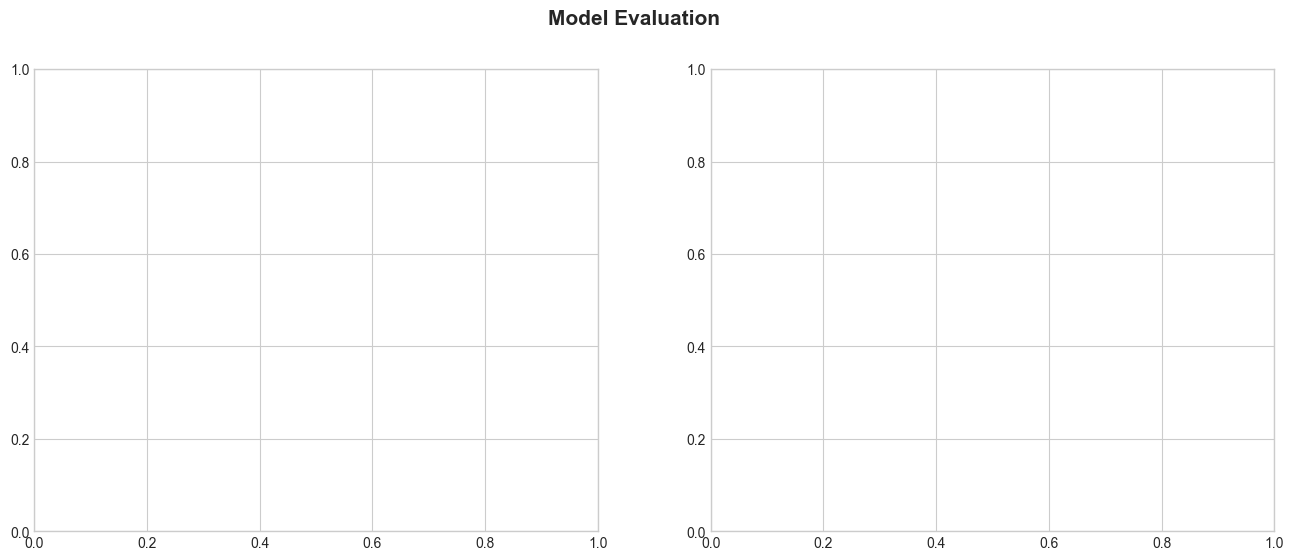

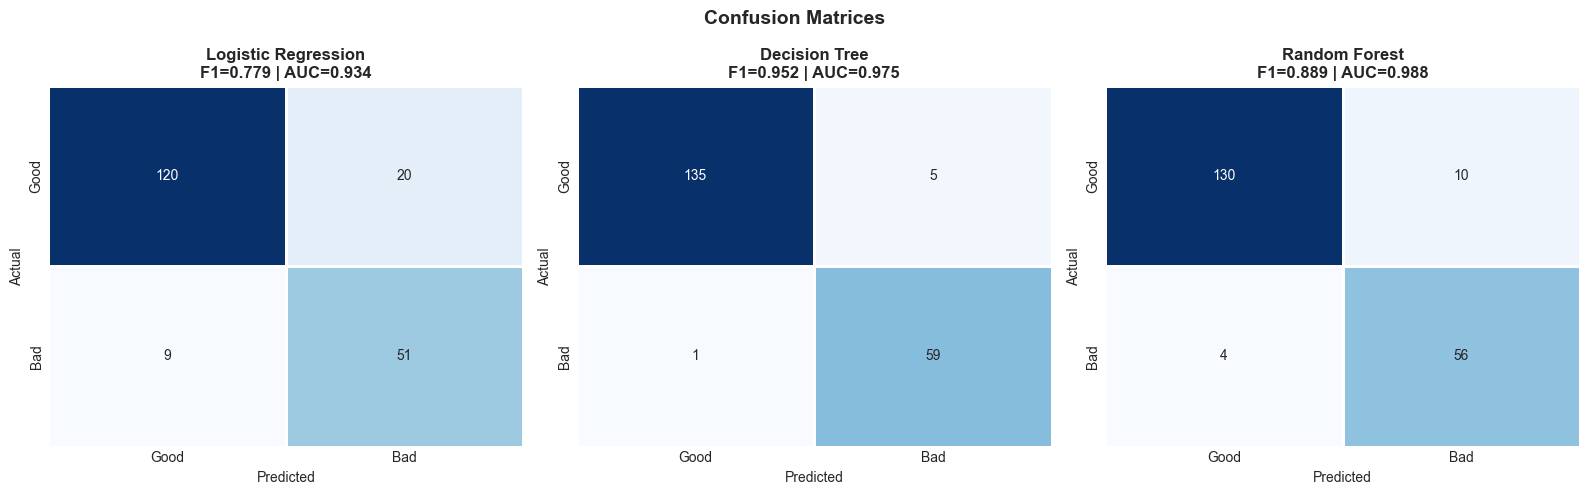

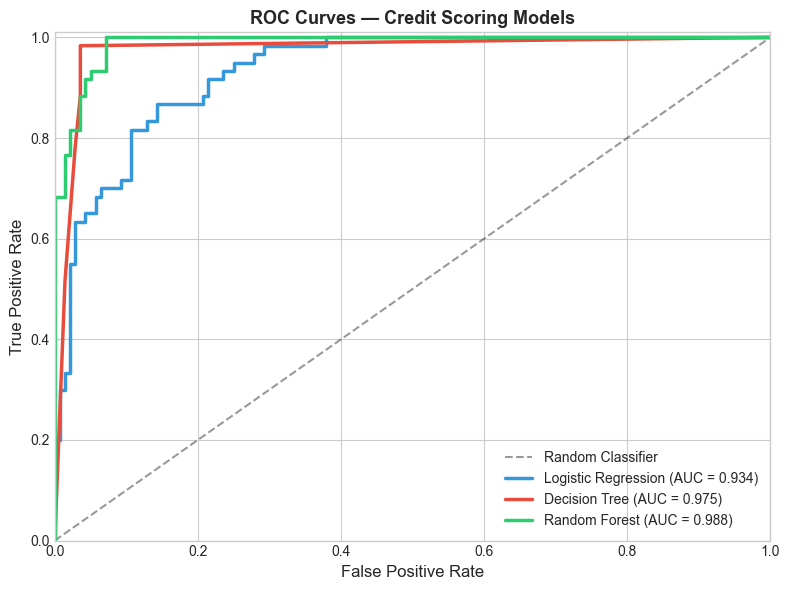

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# ── 1. Confusion Matrices ────────────────────────────────────
from matplotlib.gridspec import GridSpec
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes2, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good', 'Bad'],
                yticklabels=['Good', 'Bad'],
                linewidths=1, cbar=False)
    ax.set_title(f"{name}\nF1={res['F1-Score']:.3f} | AUC={res['ROC-AUC']:.3f}", 
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── 2. ROC Curves ────────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Classifier')

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Credit Scoring Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

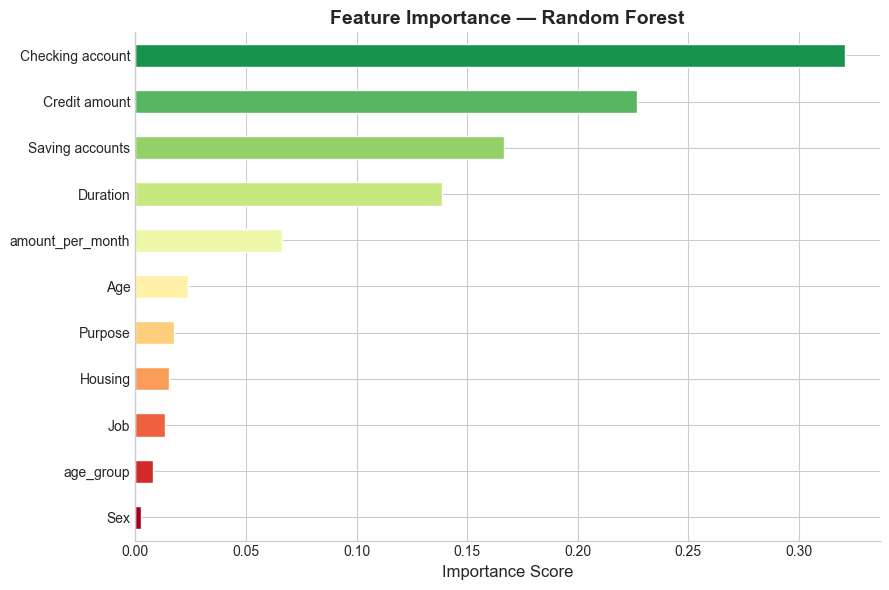

Top 5 most important features:
Checking account    0.3207
Credit amount       0.2267
Saving accounts     0.1668
Duration            0.1388
amount_per_month    0.0665


In [10]:
# ── Feature Importance ───────────────────────────────────────
rf_model = results['Random Forest']['model']

feat_importance = pd.Series(
    rf_model.feature_importances_, 
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.RdYlGn(
    [i/len(feat_importance) for i in range(len(feat_importance))]
)

feat_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Feature Importance — Random Forest', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_importance.sort_values(ascending=False).head(5).round(4).to_string())

In [11]:
# ── Final Summary ────────────────────────────────────────────
print("=" * 60)
print("        CREDIT SCORING MODEL — FINAL SUMMARY")
print("=" * 60)

print("\n📊 Model Performance:")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'AUC':>8}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<25} {res['Accuracy']:>9.4f} {res['Precision']:>10.4f} "
          f"{res['Recall']:>8.4f} {res['F1-Score']:>7.4f} {res['ROC-AUC']:>8.4f}")

print("\n🏆 Best Model: Decision Tree")
print("   → Highest Accuracy : 97.0%")
print("   → Highest F1-Score : 0.952")
print("   → ROC-AUC          : 0.975")

print("\n🔑 Top 5 Predictive Features:")
print("   1. Checking account  (0.3207) — strongest signal")
print("   2. Credit amount     (0.2267) — higher = riskier")
print("   3. Saving accounts   (0.1668) — less savings = riskier")
print("   4. Duration          (0.1388) — longer = riskier")
print("   5. Amount per month  (0.0665) — repayment burden")

print("\n💡 Key Insights:")
print("   • Bad risk borrowers request 2x more credit (5325 vs 2391)")
print("   • Bad risk loans last 11 months longer on average")
print("   • Vacation/other purpose loans have highest default rate (68%)")
print("   • Sex and age_group have almost zero predictive power")

print("\n✅ Task 1 Complete!")
print("=" * 60)

        CREDIT SCORING MODEL — FINAL SUMMARY

📊 Model Performance:
Model                      Accuracy  Precision   Recall      F1      AUC
------------------------------------------------------------
Logistic Regression          0.8550     0.7183   0.8500  0.7786   0.9344
Decision Tree                0.9700     0.9219   0.9833  0.9516   0.9752
Random Forest                0.9300     0.8485   0.9333  0.8889   0.9883

🏆 Best Model: Decision Tree
   → Highest Accuracy : 97.0%
   → Highest F1-Score : 0.952
   → ROC-AUC          : 0.975

🔑 Top 5 Predictive Features:
   1. Checking account  (0.3207) — strongest signal
   2. Credit amount     (0.2267) — higher = riskier
   3. Saving accounts   (0.1668) — less savings = riskier
   4. Duration          (0.1388) — longer = riskier
   5. Amount per month  (0.0665) — repayment burden

💡 Key Insights:
   • Bad risk borrowers request 2x more credit (5325 vs 2391)
   • Bad risk loans last 11 months longer on average
   • Vacation/other purpose loans